# Proyek Analisis Data: Beijing Multi-Site Air Quality (PRSA)
- **Nama:** Raihan Muzhaffar Athallah
- **Email:** raihanmuzhaffar18@gmail.com
- **ID Dicoding:** raihan_ahay_04

## Menentukan Pertanyaan Bisnis

**Konteks.** Dataset berisi pengukuran per jam dari 12 stasiun pemantau kualitas udara nasional di Beijing (1 Maret 2013 – 28 Februari 2017). Bayangkan kita adalah tim analis di badan pengelola lingkungan kota yang harus menentukan **di mana, kapan, dan pada kondisi cuaca apa** pengendalian polusi PM2.5 perlu diprioritaskan. PM2.5 dipilih sebagai fokus karena paling berbahaya bagi kesehatan dan memiliki baku mutu resmi (China GB 3095-2012, Kelas II): **75 µg/m³** untuk rata-rata harian dan **35 µg/m³** untuk rata-rata tahunan.

Pertanyaan bisnis (disusun dengan metode SMART):

1. **Stasiun.** Stasiun mana dari 12 stasiun yang memiliki rata-rata PM2.5 tertinggi dan terendah, dan berapa persen hari di tiap stasiun yang melampaui baku mutu harian 75 µg/m³ selama 1 Maret 2013 – 28 Februari 2017?
   *Aksi:* menentukan stasiun/wilayah prioritas pengendalian emisi.
2. **Waktu.** Pada bulan dan jam berapa rata-rata PM2.5 seluruh stasiun mencapai puncak dan titik terendah, dan berapa persen puncak lebih tinggi dibanding titik terendah, selama 1 Maret 2013 – 28 Februari 2017?
   *Aksi:* menjadwalkan pembatasan emisi dan peringatan dini pada periode rawan.
3. **Tren.** Berapa persen perubahan rata-rata PM2.5 tahunan (periode Maret–Februari) dari 2013/14 ke 2016/17, dan berapa kali lipat level terbarunya masih di atas baku mutu tahunan 35 µg/m³?
   *Aksi:* menilai apakah kebijakan berjalan dan seberapa jauh target masih tertinggal.
4. **Cuaca.** Seberapa kuat korelasi PM2.5 dengan faktor cuaca dan polutan lain, dan pada kecepatan angin berapa rata-rata PM2.5 turun di bawah 75 µg/m³, selama 1 Maret 2013 – 28 Februari 2017?
   *Aksi:* menentukan indikator cuaca untuk sistem peringatan dini.

## Import Semua Packages/Library yang Digunakan

In [1]:
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import colors as mcolors
from matplotlib.patches import Ellipse, Patch

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

# Design tokens: gray for context, one color per meaning
GRAY, BLUE, RED, GREEN = "#B8BEC7", "#2F5D8C", "#C0392B", "#2E8B6B"
INK, MUTED = "#2B2F36", "#5B6270"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "text.color": INK,
    "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E8EAEE", "axes.axisbelow": True,
})

# China Grade II PM2.5 standards (GB 3095-2012), in ug/m3
LIMIT_DAILY, LIMIT_ANNUAL = 75, 35

## Data Wrangling

### Gathering Data
Dataset terdiri dari 12 file CSV (satu file per stasiun) dengan skema yang sama. Semua file dibaca lalu digabung menjadi satu DataFrame; kolom `station` membedakan asal stasiun.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
files = sorted(DATA_DIR.glob("PRSA_Data_*.csv"))

# Read every station file and stack them
raw = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
n_files, n_rows, n_cols = len(files), len(raw), raw.shape[1]
print(f"{n_files} files -> {n_rows:,} rows x {n_cols} columns")
raw.head()

12 files -> 420,768 rows x 18 columns


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,77.00,-0.70,"1,023.00",-18.80,0.00,NNW,4.40,Aotizhongxin
1,2,2013,3,1,1,8.00,8.00,4.00,7.00,300.00,77.00,-1.10,"1,023.20",-18.20,0.00,N,4.70,Aotizhongxin
2,3,2013,3,1,2,7.00,7.00,5.00,10.00,300.00,73.00,-1.10,"1,023.50",-18.20,0.00,NNW,5.60,Aotizhongxin
3,4,2013,3,1,3,6.00,6.00,11.00,11.00,300.00,72.00,-1.40,"1,024.50",-19.40,0.00,NW,3.10,Aotizhongxin
4,5,2013,3,1,4,3.00,3.00,12.00,12.00,300.00,72.00,-2.00,"1,025.20",-19.50,0.00,N,2.00,Aotizhongxin


In [3]:
# Rows per station (1 row = 1 hour)
rows_per_station = raw["station"].value_counts().sort_index()
rows_per_station

station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64

**Insight (Gathering Data):**
- 12 file berhasil dimuat menjadi **420,768 baris × 18 kolom**; tiap stasiun memiliki 35,064 baris (1 baris = 1 jam).
- Variabel terdiri dari polutan (`PM2.5`, `PM10`, `SO2`, `NO2`, `CO`, `O3`), cuaca (`TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, `WSPM`), serta identitas (`No`, `station`).
- Waktu tersimpan terpisah di `year`, `month`, `day`, `hour`, sehingga perlu digabung menjadi satu kolom waktu sebelum dianalisis.

### Assessing Data
Kualitas data dinilai dari enam sisi: struktur/tipe data, *missing value*, duplikasi, nilai tidak valid/tidak akurat (termasuk konsistensi logis PM2.5 vs PM10), konsistensi kategori, dan *outlier*.

In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 62.1 MB


In [5]:
# Missing values per column
missing = raw.isna().sum().to_frame("missing")
missing["pct"] = missing["missing"] / len(raw) * 100
missing = missing[missing["missing"] > 0].sort_values("missing", ascending=False)
missing

,missing,pct
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
TEMP,398,0.09
PRES,393,0.09


In [6]:
# Duplicates, invalid values and timeline completeness
expected_hours = int((pd.Timestamp("2017-03-01") - pd.Timestamp("2013-03-01")) / pd.Timedelta(hours=1))
stamp = pd.to_datetime(raw[["year", "month", "day", "hour"]])
hours_per_station = stamp.groupby(raw["station"]).nunique()

conc_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "RAIN", "WSPM"]
n_dup_rows = int(raw.duplicated().sum())
n_dup_keys = int(raw.duplicated(["station", "year", "month", "day", "hour"]).sum())
n_negative = int((raw[conc_cols] < 0).sum().sum())
n_wd = raw["wd"].nunique()

print(f"Duplicate rows             : {n_dup_rows}")
print(f"Duplicate station-hours    : {n_dup_keys}")
print(f"Negative concentrations    : {n_negative}")
print(f"Wind direction categories  : {n_wd}")
print(f"Hours per station (expected {expected_hours:,}): {sorted(hours_per_station.unique())}")

Duplicate rows             : 0
Duplicate station-hours    : 0
Negative concentrations    : 0
Wind direction categories  : 16
Hours per station (expected 35,064): [np.int64(35064)]


In [7]:
# Logical check: PM10 includes PM2.5, so PM2.5 must never exceed PM10
pm_pair = raw[["PM2.5", "PM10"]].dropna()
n_pm_bad = int((pm_pair["PM2.5"] > pm_pair["PM10"]).sum())
pct_pm_bad = n_pm_bad / len(pm_pair) * 100
print(f"PM2.5 > PM10: {n_pm_bad:,} rows ({pct_pm_bad:.2f}% of rows with both values)")

# How long are the missing streaks? (decides how far we can fill gaps)
def gap_lengths(s):
    """Length of every run of consecutive missing values."""
    na = s.isna()
    run_id = (na != na.shift()).cumsum()
    runs = na.groupby(run_id).sum()
    return runs[runs > 0]

gaps = pd.concat([gap_lengths(g["PM2.5"]) for _, g in raw.groupby("station")])
pct_gaps_short = (gaps <= 6).mean() * 100
max_gap = int(gaps.max())
print(f"PM2.5 missing streaks: {len(gaps)} | <= 6 h: {pct_gaps_short:.1f}% | longest: {max_gap} h")

PM2.5 > PM10: 21,312 rows (5.18% of rows with both values)
PM2.5 missing streaks: 2837 | <= 6 h: 93.5% | longest: 343 h


In [8]:
# Outliers with the IQR rule (1.5 x IQR) and descriptive statistics
num_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return int(((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).sum())

outliers = pd.DataFrame({"n_outlier": raw[num_cols].apply(iqr_outliers), "max": raw[num_cols].max()})
outliers["pct"] = outliers["n_outlier"] / raw[num_cols].notna().sum() * 100
outliers

,n_outlier,max,pct
PM2.5,19142,999.00,4.65
PM10,14658,999.00,3.54
SO2,35566,500.00,8.64
NO2,7021,290.00,1.72
CO,28054,"10,000.00",7.01
O3,16599,"1,071.00",4.07
TEMP,0,41.60,0.00
PRES,0,"1,042.80",0.00
DEWP,0,29.10,0.00
RAIN,16520,72.50,3.93


In [9]:
# Are extreme PM2.5 values isolated spikes (sensor errors) or real episodes?
x = raw.assign(datetime=stamp).sort_values(["station", "datetime"]).reset_index(drop=True)
prev_pm = x.groupby("station")["PM2.5"].shift(1)
next_pm = x.groupby("station")["PM2.5"].shift(-1)

high = x["PM2.5"] > 500
pct_sustained = (high & ((prev_pm > 300) | (next_pm > 300))).sum() / high.sum() * 100

extreme = x[x["PM2.5"] > 800]
by_date = extreme["datetime"].dt.date.value_counts()
top2_dates = sorted(by_date.index[:2])
pct_top2 = by_date.iloc[:2].sum() / len(extreme) * 100
n_co_cap = int((raw["CO"] == raw["CO"].max()).sum())

print(f"PM2.5 > 500: {high.sum()} hours, {pct_sustained:.1f}% next to another hour > 300")
print(f"PM2.5 > 800: {len(extreme)} station-hours, {pct_top2:.0f}% on {top2_dates}")
by_date.head(5)

PM2.5 > 500: 933 hours, 99.4% next to another hour > 300
PM2.5 > 800: 17 station-hours, 88% on [datetime.date(2016, 2, 8), datetime.date(2017, 1, 28)]


datetime
2016-02-08    11
2017-01-28     4
2013-05-05     1
2014-02-15     1
Name: count, dtype: int64

In [10]:
raw[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,"412,029.00",79.79,80.82,2.00,20.00,55.00,111.00,999.00
PM10,"414,319.00",104.60,91.77,2.00,36.00,82.00,145.00,999.00
SO2,"411,747.00",15.83,21.65,0.29,3.00,7.00,20.00,500.00
NO2,"408,652.00",50.64,35.13,1.03,23.00,43.00,71.00,290.00
CO,"400,067.00","1,230.77","1,160.18",100.00,500.00,900.00,"1,500.00","10,000.00"
O3,"407,491.00",57.37,56.66,0.21,11.00,45.00,82.00,"1,071.00"
TEMP,"420,370.00",13.54,11.44,-19.90,3.10,14.50,23.30,41.60
PRES,"420,375.00","1,010.75",10.47,982.40,"1,002.30","1,010.40","1,019.00","1,042.80"
DEWP,"420,365.00",2.49,13.79,-43.40,-8.90,3.10,15.10,29.10
RAIN,"420,378.00",0.06,0.82,0.00,0.00,0.00,0.00,72.50


**Insight (Assessing Data):** ditemukan lima kelompok temuan beserta tindakan pembersihannya.

| # | Masalah | Temuan | Tindakan pada Cleaning Data |
|---|---------|--------|-----------------------------|
| 1 | *Missing value* | Ada di semua variabel numerik dan arah angin `wd`; terbanyak `CO` (4.92%), `O3` (3.16%), `NO2` (2.88%), dan `PM2.5` (2.08%). 93.5% rangkaian kosong `PM2.5` hanya berdurasi ≤ 6 jam (terpanjang 343 jam). | Interpolasi linier per stasiun untuk celah ≤ 6 jam; celah lebih panjang dibiarkan kosong agar tidak mengarang data. `wd` diisi *forward-fill* ≤ 6 jam. |
| 2 | *Inaccurate/inconsistent value* | 21,312 baris (5.18%) memiliki `PM2.5` > `PM10`, padahal PM10 mencakup PM2.5, sehingga mustahil secara fisik. | Nilai `PM10` pada baris tersebut dianggap tidak valid (NaN); `PM2.5` dipertahankan karena menjadi fokus analisis. |
| 3 | Struktur data | Waktu tersebar di `year`, `month`, `day`, `hour`; `No` hanya nomor urut. | Gabungkan menjadi `datetime`; hapus kolom yang tidak diperlukan. |
| 4 | *Outlier* | Metode IQR menandai 4.6% nilai `PM2.5` dan 7.0% nilai `CO`. Namun 99.4% pengukuran `PM2.5` > 500 diapit jam yang juga > 300 (episode berkelanjutan, bukan lonjakan sesaat). Nilai > 800 µg/m³ (17 jam-stasiun) 88% terjadi pada dua tanggal saja (2016-02-08, 2017-01-28), yaitu dini hari setelah malam Tahun Baru Imlek, serentak di banyak stasiun. `CO` = 10,000 muncul 56 kali (kemungkinan batas ukur alat). | Dipertahankan karena merupakan kejadian nyata yang justru ingin dipahami dan jumlahnya sangat kecil; rata-rata dilengkapi median dan rata-rata harian. |
| 5 | Duplikat, nilai negatif, kelengkapan waktu | Duplikat: 0; konsentrasi negatif: 0; tiap stasiun memiliki 35,064 jam lengkap; `wd` konsisten pada 16 arah angin. | Tidak perlu tindakan. |

### Cleaning Data
Langkah pembersihan mengikuti temuan pada tahap Assessing Data:
1. Gabungkan `year-month-day-hour` menjadi `datetime`, urutkan per stasiun, lalu hapus kolom `No`.
2. Isi celah pendek (≤ 6 jam) per stasiun dengan interpolasi linier, dibulatkan ke 1 desimal.
3. Tandai `PM10` < `PM2.5` sebagai tidak valid (NaN).
4. Tambahkan kolom turunan: `month`, `hour`, `season`, dan `period` (periode Maret–Februari). Periode ini dipakai karena data dimulai Maret 2013 dan berakhir Februari 2017, sehingga tahun kalender 2013 dan 2017 tidak lengkap; periode Maret–Februari memberi 4 periode dengan 12 bulan penuh agar perbandingan tahunan adil.

In [11]:
df = raw.copy()
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = (df.drop(columns=["No", "year", "month", "day", "hour"])
        .sort_values(["station", "datetime"]).reset_index(drop=True))

missing_before = df[num_cols + ["wd"]].isna().sum()

# 1) Fill short gaps (<= 6 h) inside each station series; longer gaps stay missing
df[num_cols] = df.groupby("station")[num_cols].transform(
    lambda s: s.interpolate(limit=6, limit_area="inside"))
df["wd"] = df.groupby("station")["wd"].transform(lambda s: s.ffill(limit=6))
df[num_cols] = df[num_cols].round(1)

# 2) PM10 must be >= PM2.5; violations are treated as invalid
pm10_bad = df["PM10"] < df["PM2.5"]
n_pm10_flagged = int(pm10_bad.sum())
df.loc[pm10_bad, "PM10"] = np.nan

missing_after = df[num_cols + ["wd"]].isna().sum()

# 3) Derived columns
SEASONS = {12: "Dingin", 1: "Dingin", 2: "Dingin", 3: "Semi", 4: "Semi", 5: "Semi",
           6: "Panas", 7: "Panas", 8: "Panas", 9: "Gugur", 10: "Gugur", 11: "Gugur"}
SEASON_ORDER = ["Dingin", "Semi", "Panas", "Gugur"]
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour
df["season"] = df["month"].map(SEASONS)
start_year = df["datetime"].dt.year - (df["month"] < 3).astype(int)
df["period"] = start_year.astype(str) + "/" + ((start_year + 1) % 100).astype(str).str.zfill(2)

pd.DataFrame({"before": missing_before, "after": missing_after})

,before,after
PM2.5,8739,3354
PM10,6449,24450
SO2,9021,3896
NO2,12116,5533
CO,20701,11991
O3,13277,5437
TEMP,398,1
PRES,393,1
DEWP,403,1
RAIN,390,0


In [12]:
# Export the cleaned hourly data for the Streamlit dashboard
export_cols = ["datetime", "station"] + num_cols + ["wd"]
out_dir = DATA_DIR.parent / "dashboard"
out_dir.mkdir(exist_ok=True)
df[export_cols].to_csv(out_dir / "main_data.csv", index=False, float_format="%g")
print(f"{out_dir / 'main_data.csv'} saved: {len(df):,} rows x {len(export_cols)} columns")
print("Periods:", sorted(df["period"].unique()))

dashboard/main_data.csv saved: 420,768 rows x 14 columns
Periods: ['2013/14', '2014/15', '2015/16', '2016/17']


**Insight (Cleaning Data):**
- *Missing value* turun signifikan, misalnya `PM2.5` dari 8,739 menjadi 3,354 dan `CO` dari 20,701 menjadi 11,991. Sisanya adalah celah panjang (> 6 jam) yang sengaja tidak diisi; perhitungan rata-rata otomatis mengabaikannya.
- 22,156 nilai `PM10` yang tidak konsisten dengan `PM2.5` ditandai NaN. Hal ini tidak memengaruhi pertanyaan bisnis karena fokus analisis adalah `PM2.5`.
- Data bersih berisi 420,768 baris dan disimpan sebagai `dashboard/main_data.csv`, dipakai oleh notebook ini maupun dashboard agar angka keduanya selalu sama.
- Kolom `period` menghasilkan empat periode 12 bulan penuh: 2013/14, 2014/15, 2015/16, 2016/17.

## Exploratory Data Analysis (EDA)
Eksplorasi dilakukan per pertanyaan bisnis memakai agregasi dan statistik deskriptif. Untuk dibandingkan dengan baku mutu harian, PM2.5 dirata-ratakan per hari per stasiun; hanya hari dengan ≥ 20 dari 24 jam data valid yang dihitung, sesuai praktik umum statistik baku mutu udara.

In [13]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]

def daily_mean(data, col="PM2.5", min_hours=20):
    """Daily mean per station; days with fewer than min_hours valid hours are dropped."""
    g = (data.assign(date=data["datetime"].dt.normalize())
             .groupby(["station", "date"])[col].agg(["mean", "count"]))
    return g.loc[g["count"] >= min_hours, "mean"].rename(col).reset_index()

daily = daily_mean(df)
n_days = df["datetime"].dt.normalize().nunique()
n_valid_days, n_possible_days = len(daily), n_days * df["station"].nunique()
print(f"{n_valid_days:,} valid station-days of {n_possible_days:,} possible")

17,309 valid station-days of 17,532 possible


### Explore: Pertanyaan 1 (Stasiun)

In [14]:
stations = (df.groupby("station")["PM2.5"]
              .agg(mean="mean", median="median", p95=lambda s: s.quantile(0.95), max="max"))
stations["pct_days_over"] = daily["PM2.5"].gt(LIMIT_DAILY).groupby(daily["station"]).mean() * 100
stations = stations.sort_values("mean", ascending=False)

top_st, low_st = stations.index[0], stations.index[-1]
top_mean, low_mean = stations["mean"].iloc[0], stations["mean"].iloc[-1]
gap_pct = (top_mean / low_mean - 1) * 100
overall_mean = df["PM2.5"].mean()
overall_pct_over = daily["PM2.5"].gt(LIMIT_DAILY).mean() * 100
stations

,mean,median,p95,max,pct_days_over
station,,,,,
Dongsi,86.13,61.00,259.00,737.00,43.39
Nongzhanguan,85.15,59.00,261.00,844.00,42.79
Wanshouxigong,85.03,60.00,256.00,999.00,42.62
Gucheng,83.96,60.00,247.00,770.00,42.80
Wanliu,83.43,59.00,247.00,957.00,42.85
Guanyuan,82.99,59.00,244.00,680.00,42.39
Aotizhongxin,82.86,58.00,248.00,898.00,42.40
Tiantan,82.04,58.00,244.00,821.00,41.23
Shunyi,79.73,55.00,242.00,941.00,40.93


**Insight (EDA, Pertanyaan 1):**
- **Dongsi** memiliki rata-rata PM2.5 tertinggi (**86.1 µg/m³**) dan **Dingling** terendah (**66.3 µg/m³**); stasiun tertinggi 30% lebih tinggi.
- Seluruh stasiun berada pada 66.3–86.1 µg/m³, atau 1.9–2.5 kali baku mutu tahunan (35 µg/m³).
- Persentase hari yang melampaui 75 µg/m³ berkisar 31.6% (Dingling) hingga 43.4% (Dongsi); rata-rata seluruh stasiun 40.3%.
- Median (41–61) jauh di bawah rata-rata: distribusi miring ke kanan, artinya segelintir episode polusi berat menaikkan rata-rata.

### Explore: Pertanyaan 2 (Waktu)

In [15]:
monthly = df.groupby("month")["PM2.5"].mean()
hourly = df.groupby("hour")["PM2.5"].mean()
seasonal = df.groupby("season")["PM2.5"].agg(["mean", "median"]).loc[SEASON_ORDER]
season_hour = df.pivot_table(index="hour", columns="season", values="PM2.5", aggfunc="mean")[SEASON_ORDER]

peak_m, low_m = int(monthly.idxmax()), int(monthly.idxmin())
peak_h, low_h = int(hourly.idxmax()), int(hourly.idxmin())
pct_month_gap = (monthly.max() / monthly.min() - 1) * 100
pct_hour_gap = (hourly.max() / hourly.min() - 1) * 100
pct_season_gap = (seasonal["mean"].max() / seasonal["mean"].min() - 1) * 100

win_hi_h, win_lo_h = int(season_hour["Dingin"].idxmax()), int(season_hour["Dingin"].idxmin())
win_hour_gap = (season_hour.loc[win_hi_h, "Dingin"] / season_hour.loc[win_lo_h, "Dingin"] - 1) * 100

display(monthly.round(1).rename(dict(enumerate(MONTHS, 1))).to_frame("mean PM2.5").T)
display(hourly.round(1).to_frame("mean PM2.5").T)
seasonal

month,Jan,Feb,Mar,Apr,Mei,Jun,Jul,Agu,Sep,Okt,Nov,Des
mean PM2.5,93.70,88.90,94.60,73.00,63.20,68.90,71.80,53.50,61.30,91.80,93.30,104.40


hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
mean PM2.5,87.80,87.00,84.90,82.20,79.50,76.50,74.20,73.30,74.40,76.10,77.20,77.20,76.60,76.10,75.50,74.60,74.40,75.60,78.10,82.60,86.50,88.90,89.10,88.70


,mean,median
season,,
Dingin,95.82,56.00
Semi,77.05,59.00
Panas,64.63,51.00
Gugur,82.24,55.00


**Insight (EDA, Pertanyaan 2):**
- **Bulan:** puncak pada **Des** (104.4 µg/m³) dan titik terendah pada **Agu** (53.5 µg/m³); puncak **95%** lebih tinggi.
- **Musim:** musim Dingin (Des–Feb) paling tercemar (95.8 µg/m³), musim Panas (Jun–Agu) paling bersih (64.6 µg/m³); selisih 48%. Median musim Dingin (56) hampir sama dengan musim Semi (59), sehingga tingginya rata-rata musim Dingin terutama dipicu episode polusi berat.
- **Jam:** puncak pada pukul **22:00** (89.1 µg/m³) dan terendah pukul **07:00** (73.3 µg/m³), selisih 22%.
- Pada musim Dingin pola harian jauh lebih tajam: puncak pukul 22:00 (116.7) versus terendah pukul 14:00 (80.9), selisih 44%.

### Explore: Pertanyaan 3 (Tren)

In [16]:
by_period = df.groupby("period")["PM2.5"].mean()
period_station = df.pivot_table(index="station", columns="period", values="PM2.5", aggfunc="mean")

first_p, last_p, best_p = by_period.index[0], by_period.index[-1], by_period.idxmin()
chg_total = (by_period[last_p] / by_period[first_p] - 1) * 100
chg_to_best = (by_period[best_p] / by_period[first_p] - 1) * 100
chg_rebound = (by_period[last_p] / by_period[best_p] - 1) * 100
x_over_limit = by_period[last_p] / LIMIT_ANNUAL
cut_needed = (1 - LIMIT_ANNUAL / by_period[last_p]) * 100

chg_station = (period_station[last_p] / period_station[first_p] - 1) * 100
n_st_down = int((chg_station < 0).sum())

display(by_period.round(1).to_frame("mean PM2.5").T)
period_station.assign(change_pct=chg_station).round(1).sort_values("change_pct")

period,2013/14,2014/15,2015/16,2016/17
mean PM2.5,87.10,81.40,73.00,78.00


period,2013/14,2014/15,2015/16,2016/17,change_pct
station,,,,,
Wanliu,98.40,84.00,73.60,77.70,-21.00
Changping,79.10,76.50,62.00,67.10,-15.20
Huairou,76.50,71.60,65.30,65.10,-14.90
Dingling,72.40,70.60,58.10,64.00,-11.60
Tiantan,89.20,83.20,75.50,80.30,-10.10
Aotizhongxin,88.60,85.80,76.80,80.30,-9.40
Nongzhanguan,91.70,87.70,77.90,83.30,-9.20
Shunyi,85.20,80.50,75.70,77.80,-8.70
Wanshouxigong,92.20,84.90,77.50,85.50,-7.30


**Insight (EDA, Pertanyaan 3):**
- Rata-rata PM2.5 per periode: 2013/14 = 87.1, 2014/15 = 81.4, 2015/16 = 73.0, 2016/17 = 78.0 µg/m³.
- Dari 2013/14 ke 2016/17 turun **10.5%**. Penurunan terdalam terjadi sampai 2015/16 (-16.3%), lalu **naik lagi +6.9%** pada 2016/17.
- 12 dari 12 stasiun lebih rendah pada 2016/17 dibanding 2013/14; penurunan terbesar di Wanliu (-21.0%) dan terkecil di Gucheng (-6.1%).
- Level terbaru (78.0 µg/m³) masih **2.2 kali** baku mutu tahunan 35 µg/m³; untuk mencapainya dibutuhkan penurunan sekitar 55%.

### Explore: Pertanyaan 4 (Cuaca dan Polutan Lain)

In [17]:
corr_cols = ["CO", "NO2", "SO2", "O3", "WSPM", "TEMP", "DEWP", "PRES", "RAIN"]
corr = df[["PM2.5"] + corr_cols].corr()["PM2.5"].drop("PM2.5").sort_values()
corr_spearman = df[["PM2.5"] + corr_cols].corr(method="spearman")["PM2.5"].drop("PM2.5")
corr_pm10 = df["PM2.5"].corr(df["PM10"])
pct_rain_hours = (df["RAIN"] > 0).mean() * 100

# Wind speed bins (m/s) and wind direction
WIND_BINS = [0, 0.5, 1, 1.5, 2, 3, 4, np.inf]
WIND_LABELS = ["≤0.5", "0.5–1", "1–1.5", "1.5–2", "2–3", "3–4", ">4"]
df["wind_bin"] = pd.cut(df["WSPM"], bins=WIND_BINS, labels=WIND_LABELS, include_lowest=True)
by_wind = df.groupby("wind_bin", observed=True)["PM2.5"].agg(["mean", "median", "count"])
by_dir = df.groupby("wd")["PM2.5"].mean().sort_values()

below = by_wind.index[by_wind["mean"] < LIMIT_DAILY]
first_bin_below = below[0]
calm_mean, windy_mean = by_wind["mean"].iloc[0], by_wind["mean"].iloc[-1]

display(pd.DataFrame({"pearson": corr, "spearman": corr_spearman}).sort_values("pearson", ascending=False).round(2))
display(by_wind.round(1))
by_dir.round(1).to_frame("mean PM2.5").T

,pearson,spearman
CO,0.79,0.83
NO2,0.67,0.66
SO2,0.48,0.50
DEWP,0.11,0.24
PRES,0.02,-0.07
RAIN,-0.01,-0.02
TEMP,-0.13,-0.02
O3,-0.15,-0.26
WSPM,-0.27,-0.33


,mean,median,count
wind_bin,,,
≤0.5,103.90,78.00,40912
0.5–1,101.20,76.00,93345
1–1.5,90.60,67.00,99527
1.5–2,75.50,54.00,63925
2–3,59.30,39.00,65305
3–4,41.00,20.00,29400
>4,28.60,13.00,25000


wd,NW,NNW,WNW,N,NNE,W,WSW,SW,SSW,NE,S,SSE,SE,ENE,E,ESE
mean PM2.5,51.60,53.80,56.80,67.20,71.20,73.80,77.40,79.50,84.20,86.30,89.50,93.60,96.90,97.90,101.70,102.10


**Insight (EDA, Pertanyaan 4):**
- Korelasi Pearson dengan PM2.5: `CO` **+0.79** (terkuat), `NO2` +0.67, `SO2` +0.48; sedangkan `O3` -0.15. Pada faktor cuaca, kecepatan angin paling berpengaruh (`WSPM` **-0.27**), diikuti suhu (-0.13); `DEWP` +0.11, `PRES` +0.02, dan `RAIN` -0.01 nyaris tidak berkorelasi (hujan hanya tercatat pada 3.9% jam). Korelasi Spearman menguatkan temuan ini: faktor teratas tetap `CO` (+0.83) dan, di antara variabel cuaca, `WSPM` (-0.33). PM10 sendiri berkorelasi +0.89 dengan PM2.5, wajar karena PM2.5 bagian dari PM10.
- Korelasi linear angin tergolong lemah-sedang, tetapi pola per kelas kecepatan sangat jelas: rata-rata PM2.5 **103.9 µg/m³** saat angin ≤ 0.5 m/s dan hanya **28.6 µg/m³** saat > 4 m/s (**3.6 kali** lebih rendah).
- Rata-rata PM2.5 pertama kali turun di bawah 75 µg/m³ pada kelas kecepatan angin **2–3 m/s**.
- Arah angin: rata-rata terendah saat angin dari **NW** (51.6), tertinggi dari **ESE** (102.1).

## Visualization & Explanatory Analysis
Setiap visualisasi mengikuti prinsip desain dan integritas grafis berikut:
- **Judul memuat pesan utama**; subjudul menjelaskan ukuran dan periode data; sumber data dicantumkan.
- **Warna untuk menekankan, bukan menghias**: abu-abu untuk konteks, merah untuk nilai terburuk/perhatian, hijau untuk nilai terbaik, biru untuk pembanding awal. Makna warna sama di semua grafik.
- **Sumbu nilai dimulai dari nol** pada grafik batang dan garis sehingga selisih visual sebanding dengan selisih data; satuan (µg/m³, %, m/s) selalu ditulis.
- **Label langsung** pada batang/garis, garis acuan baku mutu, *gridline* tipis, tanpa bingkai atas/kanan agar tidak ada *chart junk*.
- **Ukuran sampel (*n*)** ditampilkan ketika pengelompokan membuat jumlah data per kelompok berbeda.

In [18]:
SOURCE = "Sumber: Beijing Multi-Site Air-Quality Data (PRSA), 1 Mar 2013 – 28 Feb 2017"

def add_titles(fig, title, subtitle):
    """Left-aligned takeaway title, subtitle and source note."""
    fig.suptitle(title, x=0.01, y=0.985, ha="left", fontsize=13.5, fontweight="bold", color=INK)
    fig.text(0.01, 0.915, subtitle, ha="left", fontsize=9.5, color=MUTED)
    fig.text(0.01, 0.012, SOURCE, ha="left", fontsize=8, color=MUTED)

### Pertanyaan 1: Stasiun mana yang paling dan paling tidak tercemar?
*Stasiun mana dari 12 stasiun yang memiliki rata-rata PM2.5 tertinggi dan terendah, dan berapa persen hari di tiap stasiun yang melampaui baku mutu harian 75 µg/m³ selama 1 Maret 2013 – 28 Februari 2017?*

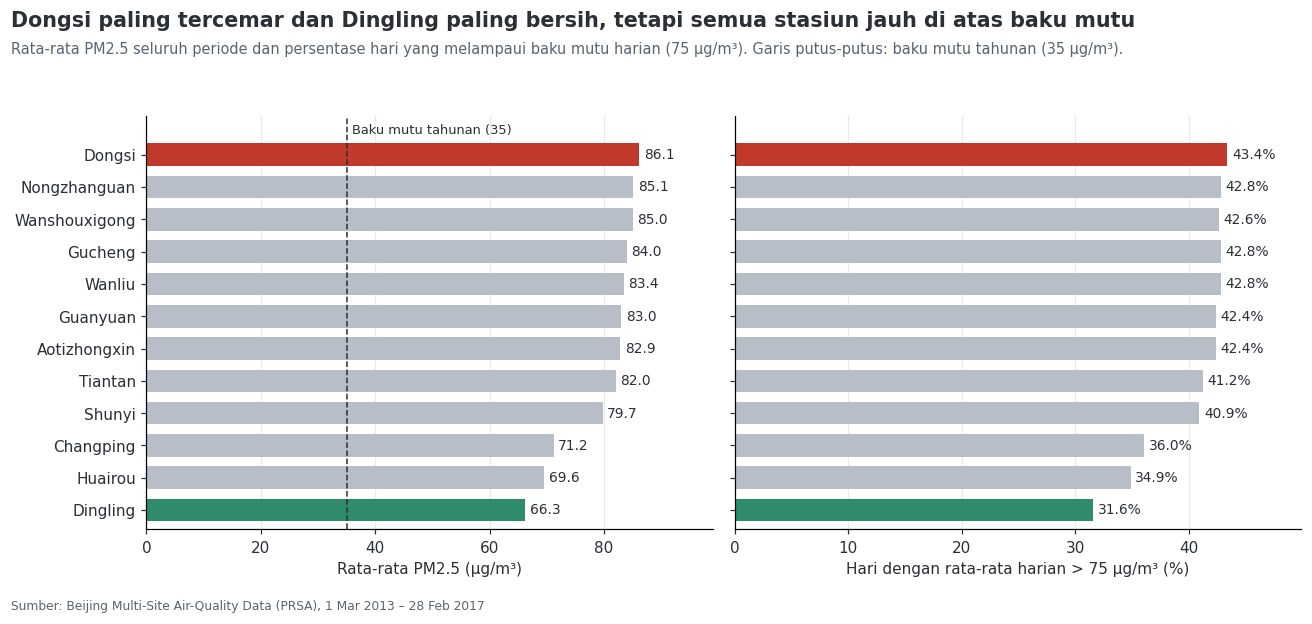

In [19]:
order = stations.index[::-1]  # barh draws bottom-up, so reverse for a top-down ranking
bar_colors = [RED if s == top_st else GREEN if s == low_st else GRAY for s in order]
panels = [("mean", "Rata-rata PM2.5 (µg/m³)", "%.1f"),
          ("pct_days_over", f"Hari dengan rata-rata harian > {LIMIT_DAILY} µg/m³ (%)", "%.1f%%")]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharey=True)
for ax, (col, label, fmt) in zip(axes, panels):
    bars = ax.barh(order, stations.loc[order, col], color=bar_colors, height=0.7)
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=9)
    ax.set_xlabel(label)
    ax.set_xlim(0, stations[col].max() * 1.15)
    ax.set_ylim(-0.6, len(order) + 0.2)
    ax.grid(axis="y", visible=False)

axes[0].axvline(LIMIT_ANNUAL, color=INK, ls="--", lw=1)
axes[0].text(LIMIT_ANNUAL + 1, len(order) - 0.45, f"Baku mutu tahunan ({LIMIT_ANNUAL})", fontsize=8.5, va="bottom")

add_titles(fig,
           f"{top_st} paling tercemar dan {low_st} paling bersih, tetapi semua stasiun jauh di atas baku mutu",
           f"Rata-rata PM2.5 seluruh periode dan persentase hari yang melampaui baku mutu harian ({LIMIT_DAILY} µg/m³). "
           f"Garis putus-putus: baku mutu tahunan ({LIMIT_ANNUAL} µg/m³).")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 1):**
- Grafik kiri memperlihatkan dua kelompok: **9 stasiun** berada pada rentang sempit 79.7–86.1 µg/m³, sedangkan **tiga stasiun terbersih** (Dingling, Huairou, Changping) jelas lebih rendah, yaitu 66.3–71.2 µg/m³.
- Grafik kanan sejalan: persentase hari yang melampaui 75 µg/m³ tertinggi di Dongsi (43.4%) dan terendah di Dingling (31.6%). Bahkan stasiun terbersih (Dingling) masih melewati baku mutu harian pada 32% hari.
- Jadi perbedaan antarstasiun nyata tetapi kecil dibanding kesenjangan terhadap baku mutu: masalahnya bersifat **regional**, bukan hanya lokal.

### Pertanyaan 2: Kapan polusi paling tinggi?
*Pada bulan dan jam berapa rata-rata PM2.5 seluruh stasiun mencapai puncak dan titik terendah, dan berapa persen puncak lebih tinggi dibanding titik terendah, selama 1 Maret 2013 – 28 Februari 2017?*

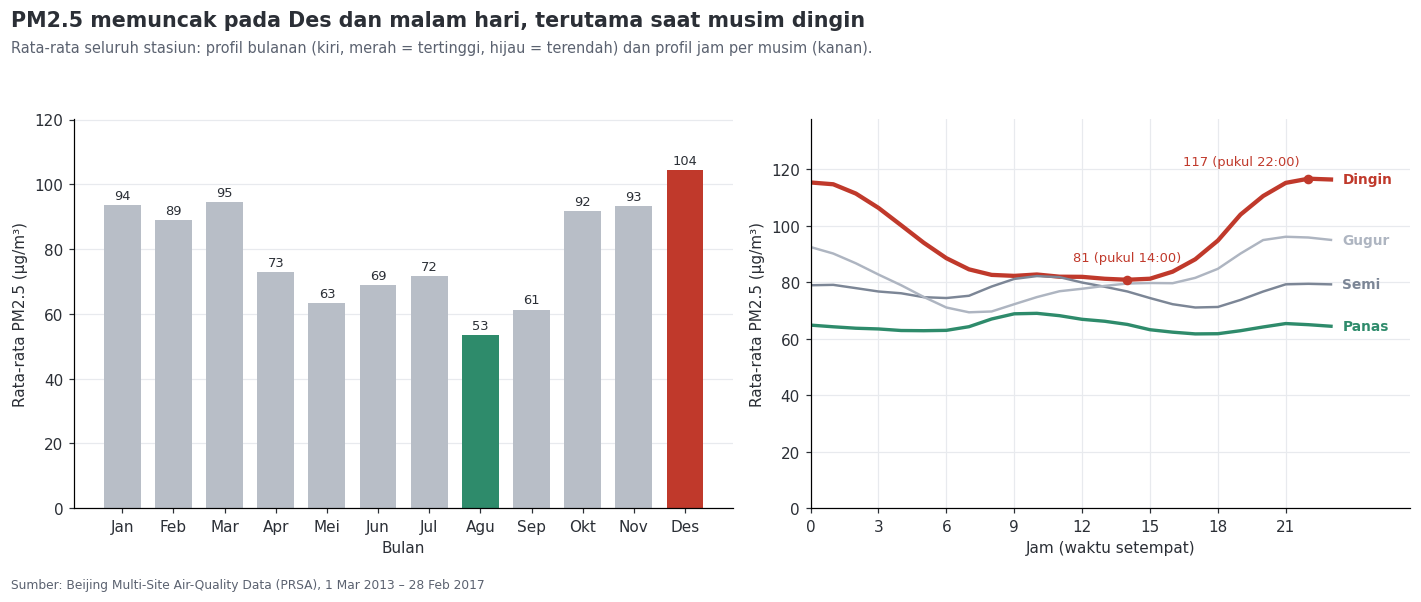

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1.1, 1]})

# Left: monthly profile
ax = axes[0]
month_colors = [RED if m == peak_m else GREEN if m == low_m else GRAY for m in monthly.index]
bars = ax.bar(MONTHS, monthly.values, color=month_colors, width=0.72)
ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8.5)
ax.set_ylabel("Rata-rata PM2.5 (µg/m³)")
ax.set_xlabel("Bulan")
ax.set_ylim(0, monthly.max() * 1.15)
ax.grid(axis="x", visible=False)

# Right: hourly profile per season, labeled directly (no legend)
ax = axes[1]
styles = {"Dingin": (RED, 2.8), "Panas": (GREEN, 2.2), "Semi": ("#7C8696", 1.6), "Gugur": ("#AEB5C1", 1.6)}
for season, (color, lw) in styles.items():
    ax.plot(season_hour.index, season_hour[season], color=color, lw=lw)
    ax.text(23.5, season_hour[season].iloc[-1], season, color=color, va="center", fontsize=9, fontweight="bold")
ax.scatter([win_hi_h, win_lo_h], season_hour.loc[[win_hi_h, win_lo_h], "Dingin"], color=RED, zorder=3, s=28)
ax.annotate(f"{season_hour.loc[win_hi_h, 'Dingin']:.0f} (pukul {win_hi_h:02d}:00)", (win_hi_h, season_hour.loc[win_hi_h, "Dingin"]),
            xytext=(-6, 9), textcoords="offset points", ha="right", fontsize=8.5, color=RED)
ax.annotate(f"{season_hour.loc[win_lo_h, 'Dingin']:.0f} (pukul {win_lo_h:02d}:00)", (win_lo_h, season_hour.loc[win_lo_h, "Dingin"]),
            xytext=(0, 12), textcoords="offset points", ha="center", fontsize=8.5, color=RED)
ax.set_xlim(0, 26.5)
ax.set_ylim(0, season_hour.max().max() * 1.18)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Jam (waktu setempat)")
ax.set_ylabel("Rata-rata PM2.5 (µg/m³)")

add_titles(fig,
           f"PM2.5 memuncak pada {MONTHS[peak_m - 1]} dan malam hari, terutama saat musim dingin",
           "Rata-rata seluruh stasiun: profil bulanan (kiri, merah = tertinggi, hijau = terendah) dan profil jam per musim (kanan).")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 2):**
- Grafik kiri: PM2.5 tinggi pada **Okt–Mar** (musim pemanas dan transisi) dan jatuh pada Apr–Sep; puncak Des (104) berbanding titik terendah Agu (53), yaitu **95% lebih tinggi**.
- Grafik kanan: musim Dingin tertinggi hampir sepanjang hari, dengan jurang terlebar pada malam hingga dini hari dan menyempit di siang hari. Ayunan hariannya juga terbesar (44% antara pukul 14:00 dan 22:00), sedangkan garis musim Panas relatif datar.
- Secara keseluruhan puncak jam jatuh pada **malam hari** (22:00) dan titik terendah pada pagi (07:00); polusi menumpuk setelah matahari terbenam dan menurun menjelang pagi.

### Pertanyaan 3: Apakah polusi membaik dari tahun ke tahun?
*Berapa persen perubahan rata-rata PM2.5 tahunan (periode Maret–Februari) dari 2013/14 ke 2016/17, dan berapa kali lipat level terbarunya masih di atas baku mutu tahunan 35 µg/m³?*

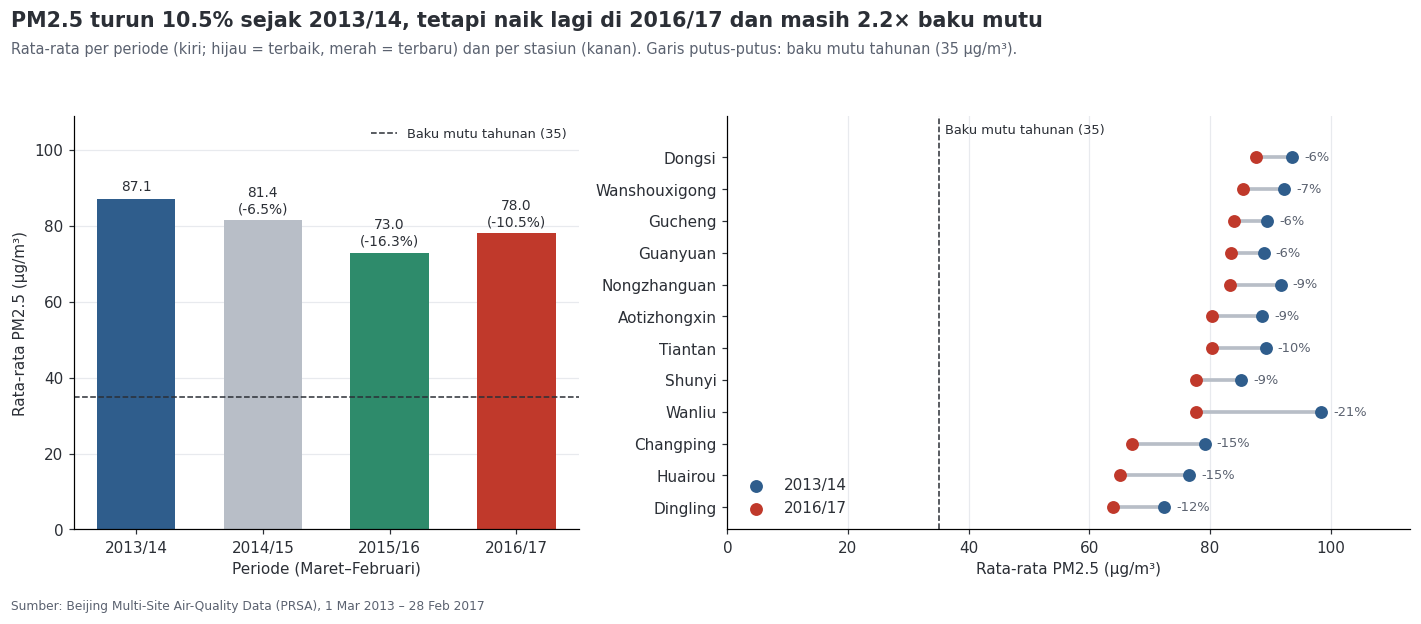

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={"width_ratios": [0.85, 1.15]})

# Left: yearly means (Mar-Feb periods)
ax = axes[0]
p_colors = [RED if p == last_p else GREEN if p == best_p else BLUE if p == first_p else GRAY for p in by_period.index]
bars = ax.bar(by_period.index, by_period.values, color=p_colors, width=0.62)
labels = [f"{v:.1f}" if p == first_p else f"{v:.1f}\n({v / by_period[first_p] - 1:+.1%})" for p, v in by_period.items()]
ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
ax.axhline(LIMIT_ANNUAL, color=INK, ls="--", lw=1, label=f"Baku mutu tahunan ({LIMIT_ANNUAL})")
ax.legend(loc="upper right", frameon=False, fontsize=8.5)
ax.set_ylim(0, by_period.max() * 1.25)
ax.set_xlabel("Periode (Maret–Februari)")
ax.set_ylabel("Rata-rata PM2.5 (µg/m³)")
ax.grid(axis="x", visible=False)

# Right: dumbbell per station, first vs last period
ax = axes[1]
ps = period_station.sort_values(last_p)
y = np.arange(len(ps))
ax.hlines(y, ps[first_p], ps[last_p], color=GRAY, lw=2.4, zorder=1)
ax.scatter(ps[first_p], y, color=BLUE, s=55, zorder=2, label=first_p)
ax.scatter(ps[last_p], y, color=RED, s=55, zorder=2, label=last_p)
for i, (first_v, last_v) in enumerate(zip(ps[first_p], ps[last_p])):
    ax.text(max(first_v, last_v) + 2, i, f"{last_v / first_v - 1:+.0%}", va="center", fontsize=8.5, color=MUTED)
ax.axvline(LIMIT_ANNUAL, color=INK, ls="--", lw=1)
ax.text(LIMIT_ANNUAL + 1, len(ps) - 0.35, f"Baku mutu tahunan ({LIMIT_ANNUAL})", fontsize=8.5, va="bottom")
ax.set_yticks(y, ps.index)
ax.set_xlim(0, ps.max().max() * 1.15)
ax.set_ylim(-0.7, len(ps) + 0.3)
ax.set_xlabel("Rata-rata PM2.5 (µg/m³)")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", frameon=False)

add_titles(fig,
           f"PM2.5 turun {abs(chg_total):.1f}% sejak {first_p}, tetapi naik lagi di {last_p} dan masih {x_over_limit:.1f}× baku mutu",
           f"Rata-rata per periode (kiri; hijau = terbaik, merah = terbaru) dan per stasiun (kanan). "
           f"Garis putus-putus: baku mutu tahunan ({LIMIT_ANNUAL} µg/m³).")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 3):**
- Grafik kiri: tren turun dari 87.1 (2013/14) ke 73.0 (2015/16), kemudian **berbalik naik** menjadi 78.0 (2016/17). Perubahan bersih 2013/14 → 2016/17 adalah **-10.5%**.
- Grafik kanan: 12 dari 12 stasiun membaik, tetapi besarnya berbeda-beda (-21% di Wanliu hingga -6% di Gucheng); perbaikan bersifat luas, bukan hanya di satu wilayah.
- Kesenjangan terhadap baku mutu masih besar: seluruh titik merah ada jauh di kanan garis 35 µg/m³. Level terbaru **2.2×** baku mutu dan butuh penurunan ±55% lagi.
- Catatan: empat periode belum cukup untuk menyimpulkan efektivitas kebijakan secara kausal karena cuaca tiap tahun berbeda.

### Pertanyaan 4: Faktor cuaca dan polutan apa yang paling terkait dengan PM2.5?
*Seberapa kuat korelasi PM2.5 dengan faktor cuaca dan polutan lain, dan pada kecepatan angin berapa rata-rata PM2.5 turun di bawah 75 µg/m³, selama 1 Maret 2013 – 28 Februari 2017?*

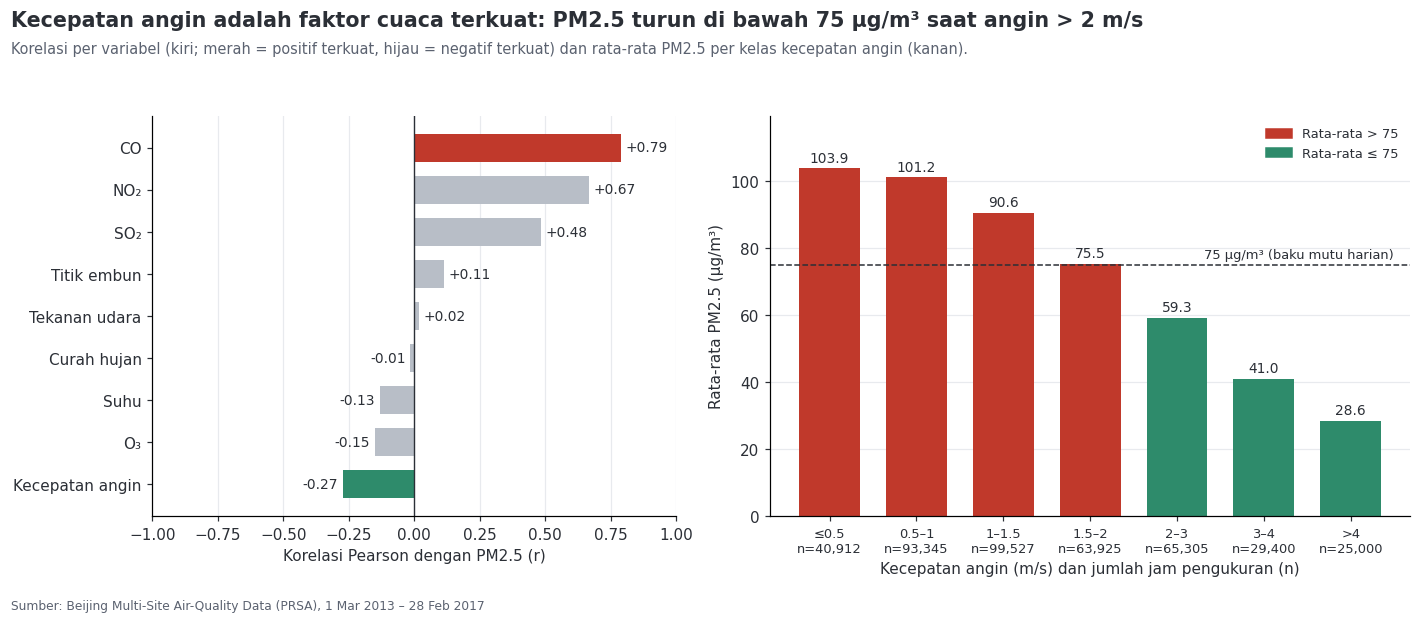

In [22]:
NAMES = {"CO": "CO", "NO2": "NO₂", "SO2": "SO₂", "O3": "O₃", "WSPM": "Kecepatan angin", "TEMP": "Suhu",
         "DEWP": "Titik embun", "PRES": "Tekanan udara", "RAIN": "Curah hujan"}
WEATHER = ["WSPM", "TEMP", "DEWP", "PRES", "RAIN"]
top_weather = corr[WEATHER].abs().idxmax()
top_pos, top_neg = corr.idxmax(), corr.idxmin()
thr = WIND_BINS[list(WIND_LABELS).index(first_bin_below)]  # lower edge of the first class below the limit

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={"width_ratios": [0.9, 1.1]})

# Left: correlation with PM2.5
ax = axes[0]
c = corr.sort_values()
c_colors = [RED if k == top_pos else GREEN if k == top_neg else GRAY for k in c.index]
bars = ax.barh([NAMES[k] for k in c.index], c.values, color=c_colors, height=0.66)
ax.bar_label(bars, fmt="%+.2f", padding=3, fontsize=9)
ax.axvline(0, color=INK, lw=0.9)
ax.set_xlim(-1, 1)
ax.set_xlabel("Korelasi Pearson dengan PM2.5 (r)")
ax.grid(axis="y", visible=False)

# Right: mean PM2.5 by wind-speed class
ax = axes[1]
w = by_wind
w_colors = [RED if m > LIMIT_DAILY else GREEN for m in w["mean"]]
bars = ax.bar(range(len(w)), w["mean"], color=w_colors, width=0.7)
ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=9)
ax.set_xticks(range(len(w)), [f"{lab}\nn={cnt:,}" for lab, cnt in zip(w.index, w["count"])], fontsize=8.5)
ax.axhline(LIMIT_DAILY, color=INK, ls="--", lw=1)
ax.text(len(w) - 0.5, LIMIT_DAILY + 2, f"{LIMIT_DAILY} µg/m³ (baku mutu harian)", ha="right", fontsize=8.5)
ax.set_ylim(0, w["mean"].max() * 1.15)
ax.set_xlabel("Kecepatan angin (m/s) dan jumlah jam pengukuran (n)")
ax.set_ylabel("Rata-rata PM2.5 (µg/m³)")
ax.grid(axis="x", visible=False)
ax.legend(handles=[Patch(color=RED, label=f"Rata-rata > {LIMIT_DAILY}"), Patch(color=GREEN, label=f"Rata-rata ≤ {LIMIT_DAILY}")],
          loc="upper right", frameon=False, fontsize=8.5)

add_titles(fig,
           f"{NAMES[top_weather]} adalah faktor cuaca terkuat: PM2.5 turun di bawah {LIMIT_DAILY} µg/m³ saat angin > {thr} m/s",
           "Korelasi per variabel (kiri; merah = positif terkuat, hijau = negatif terkuat) dan rata-rata PM2.5 per kelas kecepatan angin (kanan).")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 4):**
- Grafik kiri: **CO** paling berkorelasi positif dengan PM2.5 (r = +0.79), disusul NO₂ (+0.67) dan SO₂ (+0.48). Ketiganya terutama berasal dari pembakaran (kendaraan, pemanas, industri) dan sebagian merupakan prekursor partikel sekunder, sehingga naik-turun bersama PM2.5. Di antara faktor cuaca, **kecepatan angin** paling kuat (r = -0.27); suhu, titik embun, tekanan, dan hujan berkorelasi sangat lemah (|r| ≤ 0.13).
- Grafik kanan menunjukkan hubungan yang lebih tegas daripada angka r: rata-rata PM2.5 turun dari 104 µg/m³ (angin ≤ 0.5 m/s) menjadi 29 µg/m³ (> 4 m/s). Kelas **2–3 m/s** menjadi yang pertama dengan rata-rata di bawah 75 µg/m³.
- Maknanya: **angin tenang (< 2 m/s) adalah kondisi rawan** karena polutan tidak tersebar. Curah hujan per jam hampir tidak berkorelasi linear (sebagian besar jam bernilai 0), sehingga bukan indikator peringatan dini yang efektif dengan data ini.

## Analisis Lanjutan: Manual Grouping (Binning) dan Geospatial Analysis

Dua teknik lanjutan berikut diterapkan **tanpa algoritma *machine learning***:

1. **Manual grouping dengan *binning* (`pd.cut`).** *Tujuan:* mengubah PM2.5 yang kontinu menjadi kategori kualitas udara yang bermakna bagi kesehatan, sehingga pemangku kepentingan dapat langsung membaca "berapa persen hari yang berbahaya". Batas kelas memakai aturan resmi China AQI (HJ 633-2012) untuk rata-rata PM2.5 harian: ≤35, 35–75, 75–115, 115–150, 150–250, >250 µg/m³. Binning kedua mengelompokkan stasiun ke dalam tiga zona berdasarkan jarak dari pusat kota (≤10, 10–30, >30 km).
2. **Geospatial analysis.** *Tujuan:* melihat apakah ada pola spasial pada tingkat polusi, yakni apakah stasiun yang lebih jauh dari pusat kota lebih bersih, dengan peta statis (bubble map) dan peta interaktif (`folium`).

> **Catatan data:** dataset tidak memuat koordinat stasiun. Koordinat pada analisis ini adalah **perkiraan lokasi stasiun pemantau** yang dikompilasi manual untuk keperluan visualisasi (akurasi sekitar ratusan meter); tidak memengaruhi angka PM2.5.

### Binning 1: Kategori kualitas udara (China AQI)

In [23]:
AQI_BINS = [0, 35, 75, 115, 150, 250, np.inf]
AQI_LABELS = ["Sangat baik", "Baik", "Tercemar ringan", "Tercemar sedang", "Tercemar berat", "Tercemar sangat berat"]
AQI_COLORS = ["#2E8B6B", "#A7C77B", "#F2C14E", "#E8833A", "#C0392B", "#6C2B5A"]
AQI_TEXT = ["white", INK, INK, INK, "white", "white"]

daily["category"] = pd.cut(daily["PM2.5"], bins=AQI_BINS, labels=AQI_LABELS, include_lowest=True)
daily["season"] = daily["date"].dt.month.map(SEASONS)

overall = daily["category"].value_counts(normalize=True).reindex(AQI_LABELS) * 100
by_season_cat = pd.crosstab(daily["season"], daily["category"], normalize="index").loc[SEASON_ORDER, AQI_LABELS] * 100
share = pd.concat([overall.to_frame("Semua musim").T, by_season_cat])

clean_share = share[["Sangat baik", "Baik"]].sum(axis=1)
polluted_share = share[AQI_LABELS[2:]].sum(axis=1)
heavy_share = share[AQI_LABELS[4:]].sum(axis=1)
share.round(1)

category,Sangat baik,Baik,Tercemar ringan,Tercemar sedang,Tercemar berat,Tercemar sangat berat
Semua musim,29.60,30.10,18.20,9.50,9.20,3.40
Dingin,31.30,23.50,14.50,9.80,13.40,7.60
Semi,25.80,33.20,20.70,10.00,8.50,1.70
Panas,31.50,34.30,20.40,9.60,4.10,0.20
Gugur,29.80,29.30,17.30,8.40,11.00,4.30


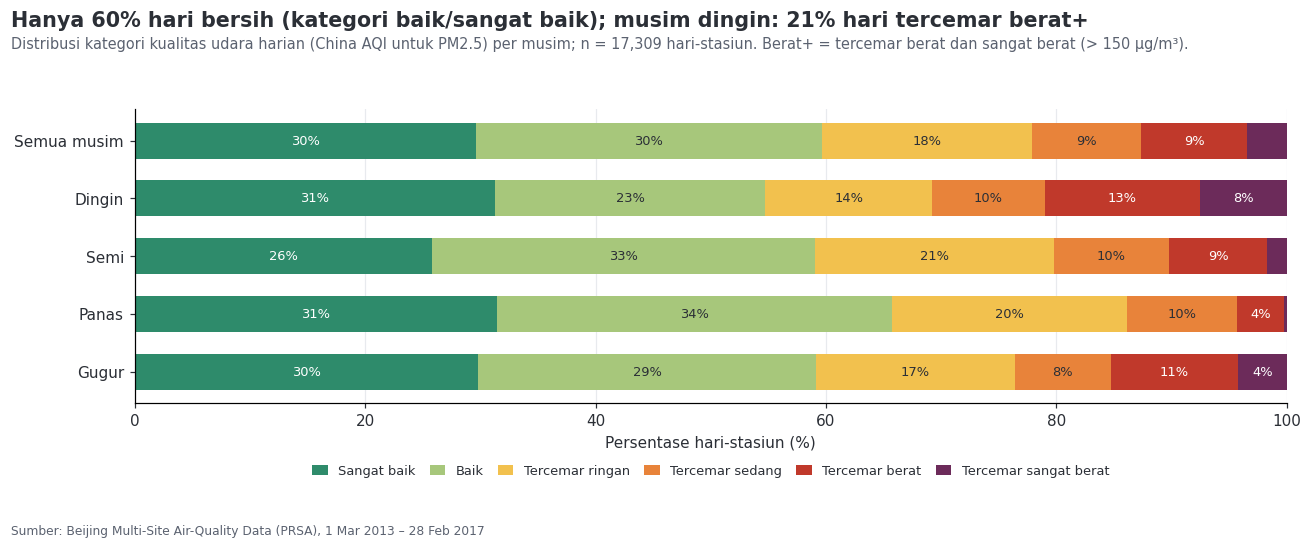

In [24]:
fig, ax = plt.subplots(figsize=(12, 4.9))
rows = share.index[::-1]  # "Semua musim" ends up on top
left = np.zeros(len(rows))
for cat, color, txt in zip(AQI_LABELS, AQI_COLORS, AQI_TEXT):
    vals = share.loc[rows, cat].values
    ax.barh(rows, vals, left=left, color=color, height=0.62, label=cat)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v >= 4:  # label only segments wide enough to read
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=8.5, color=txt)
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel("Persentase hari-stasiun (%)")
ax.grid(axis="y", visible=False)
ax.legend(ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.17), frameon=False, fontsize=8.5,
          handlelength=1.2, columnspacing=1.1)

add_titles(fig,
           f"Hanya {clean_share['Semua musim']:.0f}% hari bersih (kategori baik/sangat baik); musim dingin: {heavy_share['Dingin']:.0f}% hari tercemar berat+",
           f"Distribusi kategori kualitas udara harian (China AQI untuk PM2.5) per musim; n = {len(daily):,} hari-stasiun. Berat+ = tercemar berat dan sangat berat (> 150 µg/m³).")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Binning):**
- Hanya **60%** hari-stasiun yang masuk kategori *sangat baik* atau *baik* (≤ 75 µg/m³); **40%** tergolong tercemar ringan atau lebih buruk, dan **13%** tercemar berat atau sangat berat (> 150 µg/m³).
- Musim Dingin paling bermasalah: 21.0% hari berkategori tercemar berat+, dibanding 4.3% pada musim Panas (4.9× lebih sering). Proporsi hari bersih tertinggi ada di musim Panas (66%).
- Binning mengubah rata-rata yang tampak "sedang" menjadi informasi yang bisa ditindaklanjuti: **kejadian polusi berat** (bukan rata-rata) yang menentukan risiko kesehatan.

### Binning 2 dan Geospatial: Zona jarak dari pusat kota

In [25]:
# Approximate station locations (not in the dataset; compiled manually for visualization only)
COORDS = {
    "Aotizhongxin": (39.982, 116.397), "Changping": (40.217, 116.230), "Dingling": (40.292, 116.220),
    "Dongsi": (39.929, 116.417), "Guanyuan": (39.929, 116.339), "Gucheng": (39.914, 116.184),
    "Huairou": (40.328, 116.628), "Nongzhanguan": (39.937, 116.461), "Shunyi": (40.127, 116.655),
    "Tiantan": (39.886, 116.407), "Wanliu": (39.987, 116.287), "Wanshouxigong": (39.878, 116.352),
}
CENTER = (39.9087, 116.3975)  # Tiananmen Square

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

ZONES = ["Pusat kota (≤10 km)", "Pinggiran dalam (10–30 km)", "Pinggiran luar (>30 km)"]
geo = pd.DataFrame(COORDS, index=["lat", "lon"]).T
geo["dist_km"] = haversine_km(geo["lat"], geo["lon"], *CENTER)
geo["zone"] = pd.cut(geo["dist_km"], bins=[0, 10, 30, np.inf], labels=ZONES)
geo = geo.join(stations[["mean", "pct_days_over"]])

zone_summary = geo.groupby("zone", observed=True).agg(
    stations=("mean", "size"), mean_pm25=("mean", "mean"), pct_days_over=("pct_days_over", "mean"),
    min_dist_km=("dist_km", "min"), max_dist_km=("dist_km", "max"))
r_dist = geo["dist_km"].corr(geo["mean"])
outer = geo[geo["zone"] == ZONES[2]].sort_values("mean")
display(zone_summary.round(1))
geo.sort_values("dist_km").round(2)

,stations,mean_pm25,pct_days_over,min_dist_km,max_dist_km
zone,,,,,
Pusat kota (≤10 km),6,84.00,42.50,2.70,8.20
Pinggiran dalam (10–30 km),2,83.70,42.80,12.80,18.20
Pinggiran luar (>30 km),4,71.70,35.90,32.70,50.60


,lat,lon,dist_km,zone,mean,pct_days_over
Tiantan,39.89,116.41,2.65,Pusat kota (≤10 km),82.04,41.23
Dongsi,39.93,116.42,2.80,Pusat kota (≤10 km),86.13,43.39
Wanshouxigong,39.88,116.35,5.17,Pusat kota (≤10 km),85.03,42.62
Guanyuan,39.93,116.34,5.48,Pusat kota (≤10 km),82.99,42.39
Nongzhanguan,39.94,116.46,6.26,Pusat kota (≤10 km),85.15,42.79
Aotizhongxin,39.98,116.40,8.15,Pusat kota (≤10 km),82.86,42.40
Wanliu,39.99,116.29,12.83,Pinggiran dalam (10–30 km),83.43,42.85
Gucheng,39.91,116.18,18.22,Pinggiran dalam (10–30 km),83.96,42.80
Shunyi,40.13,116.66,32.71,Pinggiran luar (>30 km),79.73,40.93
Changping,40.22,116.23,37.13,Pinggiran luar (>30 km),71.21,36.04


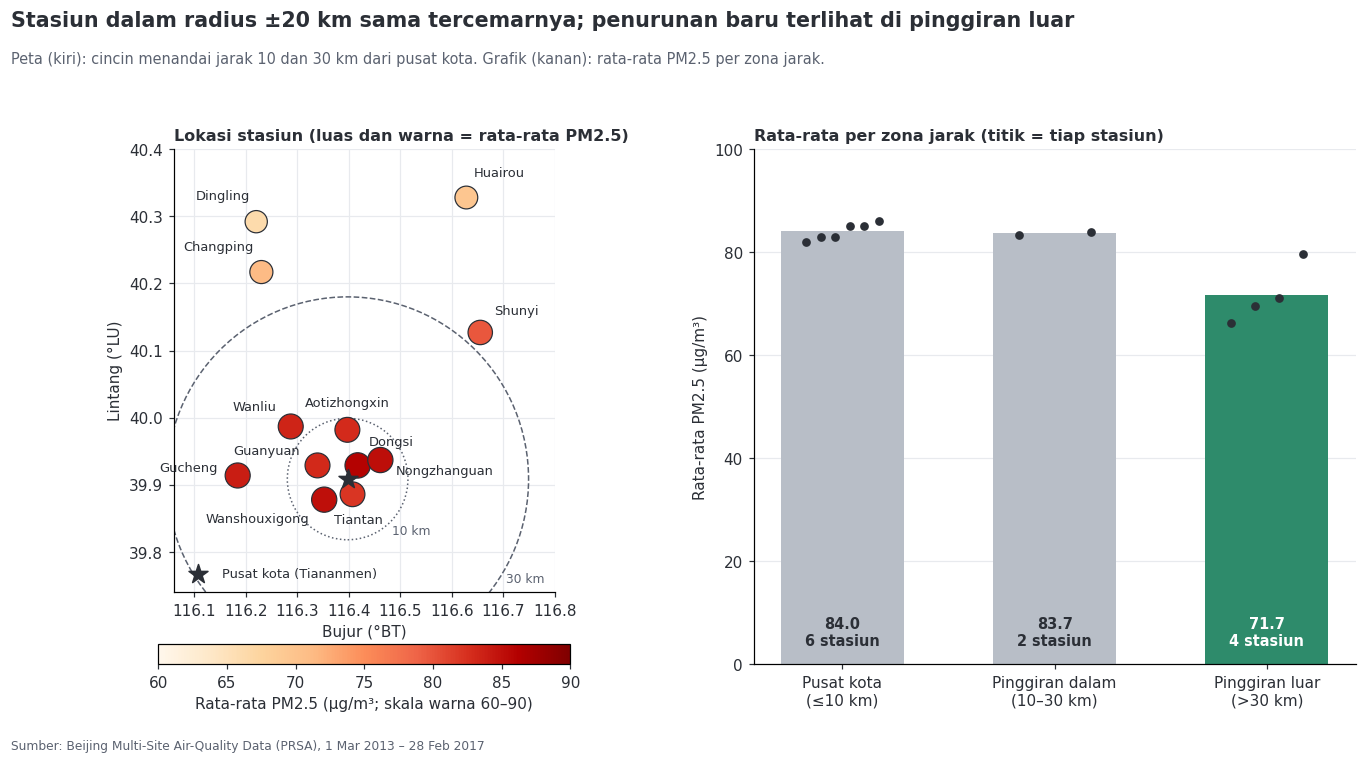

In [26]:
fig, (ax, axz) = plt.subplots(1, 2, figsize=(12.5, 6.9), gridspec_kw={"width_ratios": [1, 0.95]})
lat0 = CENTER[0]
km_lon, km_lat = 111.32 * np.cos(np.radians(lat0)), 110.57  # km per degree at this latitude

# Left: bubble map with distance rings (10 km and 30 km)
for r_km, ang, ls in [(10, -45, ":"), (30, -30, "--")]:
    ax.add_patch(Ellipse((CENTER[1], CENTER[0]), width=2 * r_km / km_lon, height=2 * r_km / km_lat,
                         fill=False, ec=MUTED, ls=ls, lw=1))
    a = np.radians(ang)
    ax.text(CENTER[1] + r_km * np.cos(a) / km_lon + 0.004, CENTER[0] + r_km * np.sin(a) / km_lat - 0.004,
            f"{r_km} km", fontsize=8, color=MUTED, ha="left", va="top")

norm = mcolors.Normalize(vmin=60, vmax=90)
sc = ax.scatter(geo["lon"], geo["lat"], s=geo["mean"] * 3.2, c=geo["mean"], cmap="OrRd", norm=norm,
                edgecolor=INK, linewidth=0.8, zorder=3)
ax.scatter(CENTER[1], CENTER[0], marker="*", s=170, color=INK, zorder=4, label="Pusat kota (Tiananmen)")

# Push labels radially away from the city center to limit overlap (manual override where they still collide)
LABEL_OFFSET = {"Dongsi": (7, 11), "Nongzhanguan": (10, -3)}
for name, row in geo.iterrows():
    dx, dy = (row["lon"] - CENTER[1]) * km_lon, (row["lat"] - CENTER[0]) * km_lat
    d = max(np.hypot(dx, dy), 1e-6)
    ox, oy = LABEL_OFFSET.get(name, (dx / d * 13, dy / d * 13))
    ax.annotate(name, (row["lon"], row["lat"]), xytext=(ox, oy), textcoords="offset points", fontsize=8.5,
                ha="center" if abs(ox) < 4 else "left" if ox > 0 else "right", va="bottom" if oy >= 0 else "top")

ax.set_aspect(1 / np.cos(np.radians(lat0)))  # keep 1 km equal in x and y
ax.set_xlim(116.06, 116.80)
ax.set_ylim(39.74, 40.40)
ax.set_xlabel("Bujur (°BT)")
ax.set_ylabel("Lintang (°LU)")
ax.set_title("Lokasi stasiun (luas dan warna = rata-rata PM2.5)", fontsize=10.5)
ax.legend(loc="lower left", frameon=False, fontsize=8.5)
fig.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.04, pad=0.1,
             label="Rata-rata PM2.5 (µg/m³; skala warna 60–90)")

# Right: mean PM2.5 per distance zone, dots = individual stations
z = zone_summary
bars = axz.bar(range(len(z)), z["mean_pm25"], color=[GRAY, GRAY, GREEN], width=0.58)
for i, (zone, row) in enumerate(z.iterrows()):
    pts = geo.loc[geo["zone"] == zone, "mean"].sort_values()
    axz.scatter(i + np.linspace(-0.17, 0.17, len(pts)) if len(pts) > 1 else [i], pts, color=INK, s=22, zorder=3)
    axz.text(i, 3, f"{row['mean_pm25']:.1f}\n{int(row['stations'])} stasiun", ha="center", va="bottom", fontsize=9.5,
             fontweight="bold", color="white" if i == len(z) - 1 else INK)
axz.set_xticks(range(len(z)), [name.replace(" (", "\n(") for name in z.index])
axz.set_ylim(0, 100)
axz.set_ylabel("Rata-rata PM2.5 (µg/m³)")
axz.set_title("Rata-rata per zona jarak (titik = tiap stasiun)", fontsize=10.5)
axz.grid(axis="x", visible=False)

add_titles(fig,
           "Stasiun dalam radius ±20 km sama tercemarnya; penurunan baru terlihat di pinggiran luar",
           "Peta (kiri): cincin menandai jarak 10 dan 30 km dari pusat kota. Grafik (kanan): rata-rata PM2.5 per zona jarak.")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

In [27]:
# Interactive map: marker size and color follow mean PM2.5
cmap = plt.get_cmap("OrRd")
m = folium.Map(location=[40.02, 116.40], zoom_start=9, tiles="OpenStreetMap", control_scale=True)
for name, row in geo.iterrows():
    popup = (f"<b>{name}</b><br>Rata-rata PM2.5: {row['mean']:.1f} µg/m³<br>"
             f"Hari > {LIMIT_DAILY} µg/m³: {row['pct_days_over']:.1f}%<br>"
             f"Jarak dari pusat kota: {row['dist_km']:.0f} km<br>Zona: {row['zone']}")
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=row["mean"] / 4.5, weight=1.2, color=INK,
        fill=True, fill_color=mcolors.to_hex(cmap(norm(row["mean"]))), fill_opacity=0.85,
        tooltip=f"{name}: {row['mean']:.1f} µg/m³", popup=folium.Popup(popup, max_width=260),
    ).add_to(m)
folium.CircleMarker(list(CENTER), radius=5, color=INK, fill=True, fill_color=INK, tooltip="Pusat kota (Tiananmen)").add_to(m)
m

**Insight (Geospatial):**
- Rata-rata PM2.5 menurut zona: **Pusat kota (≤10 km)** = 84.0 µg/m³ (6 stasiun); **Pinggiran dalam (10–30 km)** = 83.7 µg/m³ (2 stasiun); **Pinggiran luar (>30 km)** = 71.7 µg/m³ (4 stasiun).
- Pusat kota dan pinggiran dalam nyaris sama; penurunan baru muncul di pinggiran luar, itupun tidak seragam: Dingling 66.3, Huairou 69.6, Changping 71.2, Shunyi 79.7 µg/m³. Korelasi jarak–PM2.5 antarstasiun r = -0.92 (n = 12, hanya indikatif).
- Pola ini konsisten dengan pencemaran **regional**, bukan sekadar emisi kota inti: pada EDA, angin dari arah ESE/E/SE membawa PM2.5 tertinggi, sedangkan angin NW/NNW/WNW membawa udara paling bersih. Hipotesis ini perlu diuji dengan data emisi dan trajektori angin yang tidak tersedia di dataset.

## Conclusion

- **Kesimpulan Pertanyaan 1 (stasiun):** **Dongsi** paling tercemar (86.1 µg/m³) dan **Dingling** paling bersih (66.3 µg/m³), selisih 30%. Seluruh stasiun berada 1.9–2.5× di atas baku mutu tahunan dan melampaui baku mutu harian pada 32–43% hari. Tiga stasiun terbersih (Dingling, Huairou, Changping) berada di sisi utara kota, sedangkan 9 stasiun lain nyaris setara (80–86 µg/m³).
- **Kesimpulan Pertanyaan 2 (waktu):** PM2.5 memuncak pada **Des** (104 µg/m³), 95% lebih tinggi dari titik terendah di **Agu** (53). Per jam, puncak terjadi pukul **22:00** (89) dan terendah pukul 07:00 (73), selisih 22%. Kombinasi terburuk adalah **malam musim dingin**: 117 µg/m³ pukul 22:00.
- **Kesimpulan Pertanyaan 3 (tren):** rata-rata PM2.5 turun **10.5%** dari 87.1 (2013/14) ke 78.0 µg/m³ (2016/17), tetapi sempat terendah di 2015/16 (73.0) lalu naik 6.9%. Level terbaru masih **2.2×** baku mutu tahunan; dibutuhkan penurunan ±55% lagi.
- **Kesimpulan Pertanyaan 4 (cuaca):** **CO** (r = +0.79), NO₂ (+0.67) dan SO₂ (+0.48) paling terkait dengan PM2.5, sedangkan faktor cuaca terkuat adalah **kecepatan angin** (r = -0.27). Rata-rata PM2.5 3.6× lebih tinggi saat angin ≤ 0.5 m/s dibanding > 4 m/s dan baru turun di bawah 75 µg/m³ pada angin > 2 m/s.
- **Analisis lanjutan:** hanya 60% hari-stasiun berkategori baik; hari tercemar berat+ 21.0% pada musim Dingin vs 4.3% pada musim Panas. Secara spasial, pusat kota dan pinggiran dalam setara (84 dan 84 µg/m³), sedangkan pinggiran luar lebih rendah (72 µg/m³), indikasi pencemaran regional.

### Rekomendasi (Action Items)
1. **Prioritaskan wilayah dan musim.** Fokuskan pengendalian emisi serta penempatan sensor/penegakan aturan pada zona pusat–pinggiran dalam (rata-rata ±84 µg/m³), dimulai dari Dongsi, Nongzhanguan, Wanshouxigong, dan jadwalkan pembatasan emisi musiman (pemanas, kendaraan diesel berat, konstruksi) pada **Okt–Mar**.
2. **Bangun peringatan dini berbasis angin dan CO/NO₂.** Aktifkan status siaga ketika kecepatan angin **< 2 m/s** (rata-rata PM2.5 di atas 75 µg/m³), terutama pada malam musim dingin; gunakan CO dan NO₂ sebagai indikator pendamping karena korelasinya tertinggi.
3. **Targetkan jam rawan.** Terapkan pembatasan emisi dan imbauan publik pada **malam hari (±19:00–00:00)**, saat konsentrasi memuncak, mis. pengaturan jam operasional truk diesel dan sumber pembakaran.
4. **Evaluasi dan perketat pembatasan kembang api Imlek.** Nilai ekstrem > 800 µg/m³ sebagian besar muncul serentak di banyak stasiun pada dini hari setelah malam Tahun Baru Imlek (2016-02-08, 2017-01-28); waktunya bertepatan dengan tradisi kembang api tengah malam, sehingga diduga terkait dan perlu diverifikasi dengan data komposisi partikel.
5. **Tetapkan target dan evaluasi tahunan.** Pantau metrik rata-rata periode Maret–Februari terhadap baku mutu 35 µg/m³ (butuh ±55% penurunan dari level 2016/17) dan selidiki penyebab kenaikan 6.9% pada 2016/17.
6. **Lengkapi data untuk analisis berikutnya.** Tambahkan data emisi, lalu lintas, ketinggian lapisan batas, dan data setelah Februari 2017 untuk menguji hipotesis pencemaran regional dan menilai efektivitas kebijakan secara kausal.